In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Standard model without seasonality

In [2]:
class Parameters:
    def __init__(self, ncells=100, z=20):
        self.w = 0.1  # Velocity in m/d
        self.z = z # Depth in m
        # self.kappa = 0.3    # Mixing rate (m/day)

        # Define grid
        self.ncells = ncells  # Number of cells
        self.dz = self.z / self.ncells  # Cell size in m
        self.grid = np.arange(self.dz/2, self.z + self.dz/2, self.dz)  # Grid points at cell centers

        # parameters for phytoplankton growth
        self.kN = 0.3       # Nutrient half-saturation constant (umolN/m3)
        self.kL = 20.0      # Light half-saturation constant (umol photons/m2/s)
        self.gPmax = 2.0    # Maximum growth rate (1/day)
        self.mP = 0.07      # Mortality rate (1/day)

        # parameters for nutrients
        self.Ndeep = 10.0   # Deep nutrient concentration (umolN/m3)

        # parameters for zooplankton
        self.gZmax = 1.0    # Maximum grazing rate (1/day)
        self.eresp = 0.3    # respiration rate (xx)
        self.egestion = 0.3 # egestion rate (xx)
        self.mZ = 0.2      # mortality rate (1/day)
        self.kZ = 1         # Grazing half-saturation constant (umolN/m3)

        # parameters for detritus
        self.r = 0.1        # remineralization rate (1/day)

        # parameters for time step
        self.dt = 1  # time step in days
        self.t_end = 365  # total simulation time in days
        self.t = np.arange(0, self.t_end + self.dt, self.dt)  # time array

        # constant light
        self.IO = np.full(self.ncells, 100) # light intensity (umol photons/m2/s)
        self.kw = 0.15 # light attenuation by sea water [m-1]
        self.kp = 0.05 #0.05 # light attenuation by plankton [m2/mmolN]

        # oxygen processes
        self.yP = 9 # oxygen produced per unit of phytoplankton growth (mmolO2/mmolN)
        self.yN = 6.625 # oxygen consumed per unit of zooplankton respiration (mmolO2/mmolN)
        self.kO2_surf = 10 # oxygen mixing at surface (m/d)
        self.kO2_bott = 1 # oxygen mixing at bottom (m/d)
        self.O2_eq = 260 # oxygen concentration in equilibrium with atm at 15oC and 35 PSU (mmolO2/m3)
        self.O2crit = 100 # critical oxygen concentration for zooplankton respiration

        # diffusivity parameters:
        self.kappa_surface = 10  # Diffusivity at the surface (m²/d) (done)
        self.kappa_bottom = 5   # Diffusivity at the bottom (m²/d) (done)
        self.z_mix = 10  # Depth of the mixing layer (m) (done)
        self.zeta_mix = 10 #(done)
        self.phi_mix = 2 # wdith of the pycnocline (m)
        self.phi_max_steep = 4 # steepness of the transition in diffusivity
        self.t_max_spring = 75 # days
        self.z_mix_winter = self.z # assume fully mixed in winter

# Varying diffusivity with depth
def kappa(p, z):
    # z_mix = 5  # Mixing depth in m
    # zeta_mix = 10  # Thickness of the transition layer in m
    kappa = 0.5 * (1.0 - np.tanh((z - p.z_mix)/p.phi_mix)) * (p.kappa_surface - p.kappa_bottom) + p.kappa_bottom
    # kappa = kappa + 0.2  # Ensure kappa is larger than 0
    return kappa

def light_damping(p, P):
    IO = p.IO * np.exp(-p.kw*p.grid - np.cumsum(P*p.dz*p.kp))
    return IO

def flux(p, kappa, phi):
    Ja = np.zeros(p.ncells + 1)  # Initialize advection flux array
    Jd = np.zeros(p.ncells + 1)  # Initialize diffusion flux array
    J = np.zeros(p.ncells + 1)   # Initialize total flux array

    # Advection flux at interior points
    Ja[0] = 0  # No flux at the surface
    Ja[1:p.ncells+1] = p.w * phi[0:p.ncells]
    Ja[-1] = 0  # No flux at the bottom

    # Diffusion flux at interior points
    K = kappa(p,p.grid)
    Jd[0] = 0  # No flux at the surface
    Jd[1:p.ncells] = -K[1:p.ncells] * (phi[1:p.ncells] - phi[0:p.ncells - 1]) / p.dz
    Jd[-1] = 0  # No flux at the bottom

    # Total flux is sum of advection and diffusion fluxes
    J = Ja + Jd
    return J

def calc_uptake(p, N, P, O):
    IO = light_damping(p,P)
    gP = np.minimum(N/(p.kN + N), IO/(p.kL + IO)) 

    fO = 1/(1+np.exp(p.O2crit-O)) # oxygen limitation function, with a sharp transition around O=100 mmolO2/m3
    gZ = p.gZmax * P/(p.kZ + P) * fO           # Grazing rate from zooplankton
    return gP, gZ, IO

def derivatives(t, state, p):
    P = state[0:p.ncells]  # Phytoplankton concentration
    N = state[p.ncells:2*p.ncells]  # Nutrient concentration
    Z = state[2*p.ncells:3*p.ncells]  # Zooplankton concentration
    D = state[3*p.ncells:4*p.ncells]  # Detritus concentration
    O = state[4*p.ncells:] # Oxygen concentration

    JP = flux(p, kappa, P)  # Calculate flux based on phytoplankton concentration
    JN = flux(p, kappa, N)  # Calculate flux based on nutrient concentration
    JZ = flux(p, kappa, Z)  # Calculate flux based on zooplankton concentration
    JD = flux(p, kappa, D)  # Calculate flux based on detritus concentration
    JO = flux(p, kappa, O)  # Calculate flux based on oxygen concentration

    # No flux at surface for all components
    JP[0], JN[0], JZ[0], JD[0] = 0,0,0,0

    # Oxygen surface air–water exchange
    JO[0] = p.kO2_surf * (p.O2_eq - O[0])

    # Oxygen bottom sediment sink (O_sed = 0)
    JO[p.ncells] = -p.kO2_bott * (0.0 - O[-1])

    dPdt = np.zeros_like(P)
    dNdt = np.zeros_like(N)
    dZdt = np.zeros_like(Z)
    dDdt = np.zeros_like(D)
    dOdt = np.zeros_like(O)

    gP, gZ, _ = calc_uptake(p, N, P, O)

    dPdt = -(JP[1:p.ncells+1] - JP[0:p.ncells]) / p.dz + \
            gP*P - \
            gZ*Z - \
            p.mP*P

    dNdt = -(JN[1:p.ncells+1] - JN[0:p.ncells]) / p.dz + \
            -gP*P + \
            p.eresp*gZ*Z + \
            p.r*D

    dZdt = -(JZ[1:p.ncells+1] - JZ[0:p.ncells]) / p.dz + \
            (1-p.eresp-p.egestion)*gZ*Z - \
            p.mZ*Z
    
    dDdt = -(JD[1:p.ncells+1] - JD[0:p.ncells]) / p.dz + \
            p.mP*P + \
            p.mZ*Z + \
            p.egestion*gZ*Z - \
            p.r*D
    
    dOdt = -(JO[1:p.ncells+1] - JO[0:p.ncells]) / p.dz + \
            p.yP*gP*P - \
            p.yN*p.eresp*gZ*Z - \
            p.yN*p.r*D

    return np.concatenate([dPdt, dNdt, dZdt, dDdt, dOdt])

def run_AD_model():
    # Initialize parameters
    p = Parameters()
    
    # Initial condition Phyt: concentration is 1 everywhere except at the surface
    Phy0 = np.ones(p.ncells)
    # Phy0[0] = 1.0  # initial concentration at surface
    
    # Initial condition Nutrient: concentration is 10 mmolN/m3 everywhere
    Nut0 = np.ones(p.ncells) * 1
    
    # Initial condition Zooplankton: concentration is 1 everywhere
    Zoo0 = np.ones(p.ncells)
    # Zoo0[0] = 1.0  # initial concentration at surface

    # Initial condition Detritus: concentration is 1 everywhere
    D0 = np.ones(p.ncells)
    # D0[0] = 1.0  # initial concentration at surface

    # Initial condition Oxygen: concentration is 1 everywhere
    O0 = np.ones(p.ncells)
    # O0[0] = 1.0  # initial concentration at surface

    # Combine initial conditions
    initial_state = np.concatenate([Phy0, Nut0, Zoo0, D0, O0])

    # Time integration using scipy.integrate.odeint
    scale = 1
    t_end = scale*365
    t_span = (0, t_end)
    t = np.linspace(t_span[0], t_span[1], scale*2000) # time steps = 2000
    solution = solve_ivp(derivatives, [0, t_end], initial_state, args=(p,), t_eval=t, method='LSODA')

    return solution

In [3]:
p = Parameters()
solution = run_AD_model()

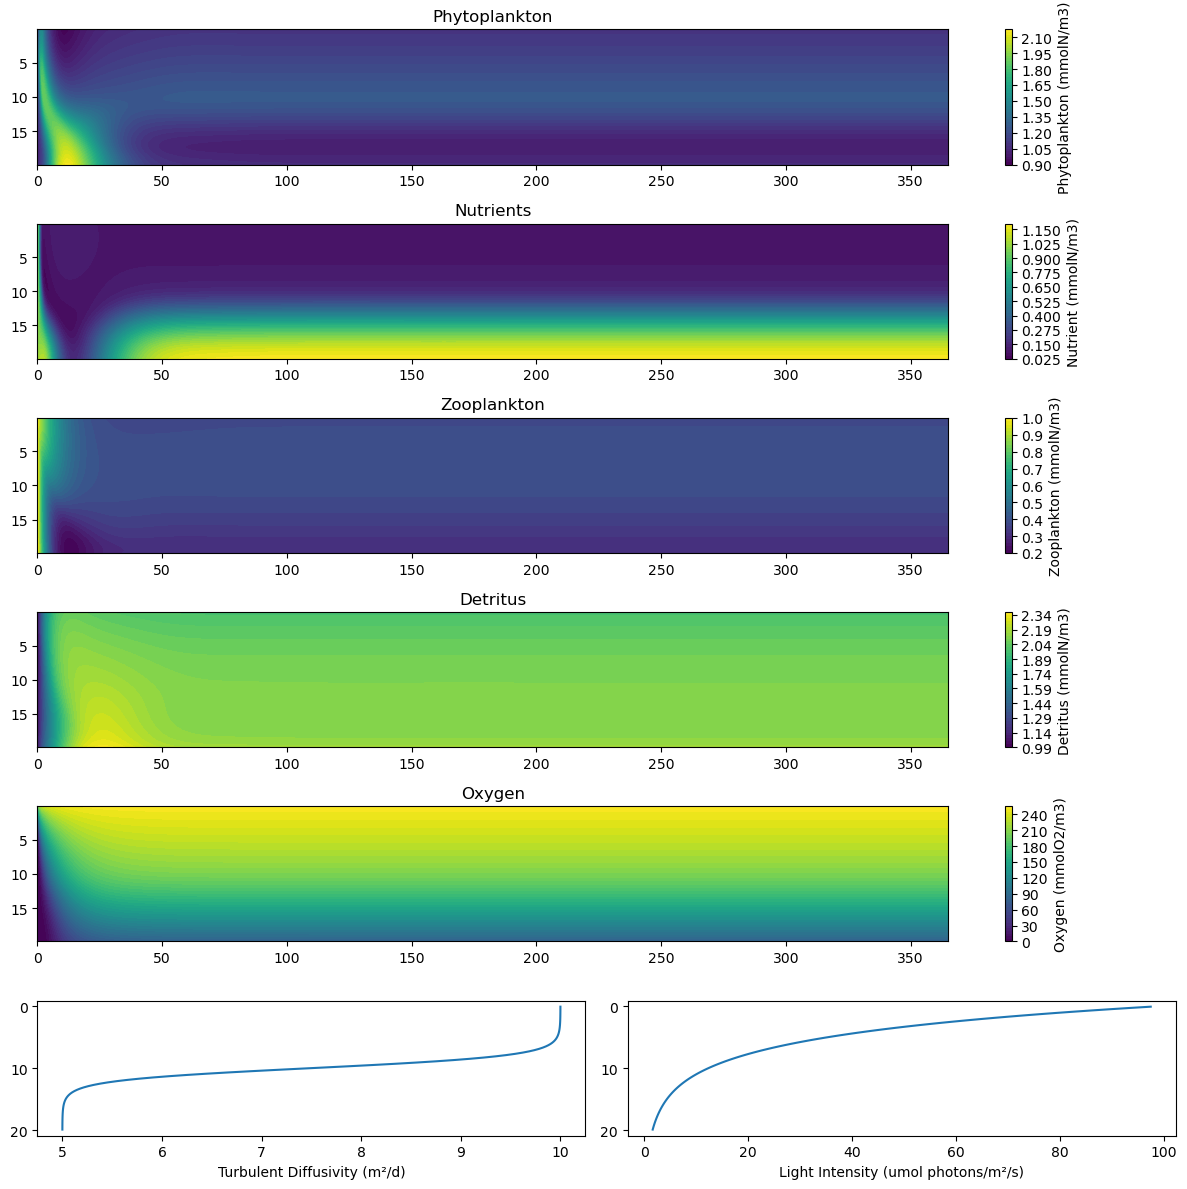

In [4]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(12, 12))
gs = GridSpec(6, 2, height_ratios=[1,1,1,1,1,1])  # 6 rows, 2 columns

# ----- Row 1: full width -----
ax1 = fig.add_subplot(gs[0, :])
c1 = ax1.contourf(solution.t, p.grid, solution.y[0:p.ncells, :], levels=50, cmap='viridis')
fig.colorbar(c1, ax=ax1, label='Phytoplankton (mmolN/m3)')
ax1.invert_yaxis()
ax1.set_title("Phytoplankton")

# ----- Row 2: full width -----
ax2 = fig.add_subplot(gs[1, :])
c2 = ax2.contourf(solution.t, p.grid, solution.y[p.ncells:2*p.ncells, :], levels=50, cmap='viridis')
fig.colorbar(c2, ax=ax2, label='Nutrient (mmolN/m3)')
ax2.invert_yaxis()
ax2.set_title("Nutrients")

# ----- Row 3: full width -----
ax3 = fig.add_subplot(gs[2, :])
c3 = ax3.contourf(solution.t, p.grid, solution.y[2*p.ncells:3*p.ncells, :], levels=50, cmap='viridis')
fig.colorbar(c3, ax=ax3, label='Zooplankton (mmolN/m3)')
ax3.invert_yaxis()
ax3.set_title("Zooplankton")

# ----- Row 4: full width -----
ax4 = fig.add_subplot(gs[3, :])
c4 = ax4.contourf(solution.t, p.grid, solution.y[3*p.ncells:4*p.ncells, :], levels=50, cmap='viridis')
fig.colorbar(c4, ax=ax4, label='Detritus (mmolN/m3)')
ax4.invert_yaxis()
ax4.set_title("Detritus")

# ----- Row 5: full width -----
ax5 = fig.add_subplot(gs[4, :])
c5 = ax5.contourf(solution.t, p.grid, solution.y[4*p.ncells:, :], levels=50, cmap='viridis')
fig.colorbar(c5, ax=ax5, label='Oxygen (mmolO2/m3)')
ax5.invert_yaxis()
ax5.set_title("Oxygen")

# ----- Row 5: two plots side by side -----
# Left plot: kappa
ax6 = fig.add_subplot(gs[5, 0])
ax6.plot(kappa(p, p.grid), p.grid)
ax6.invert_yaxis()
ax6.set_xlabel("Turbulent Diffusivity (m²/d)")

# Right plot: light
ax7 = fig.add_subplot(gs[5, 1])
IO = light_damping(p, solution.y[0:p.ncells,-1])
ax7.plot(IO.T, p.grid)
ax7.invert_yaxis()
ax7.set_xlabel("Light Intensity (umol photons/m²/s)")

plt.tight_layout()
plt.show()

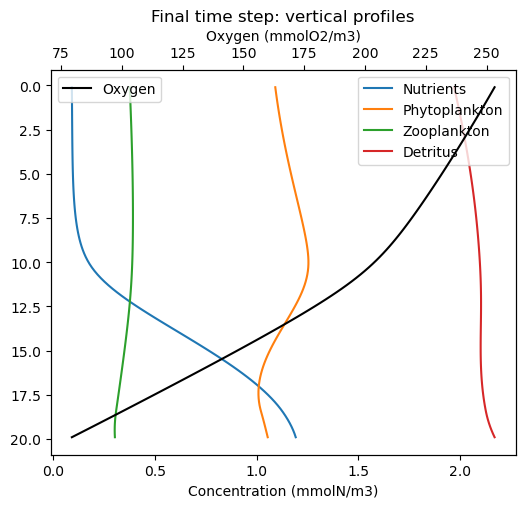

In [5]:
p = Parameters()

Pf = solution.y[0:p.ncells, -1]
Nf = solution.y[p.ncells:2*p.ncells, -1]
Zf = solution.y[2*p.ncells:3*p.ncells, -1]
Df = solution.y[3*p.ncells:4*p.ncells, -1]
Of = solution.y[4*p.ncells:, -1]

plt.figure(figsize=(6,5))
plt.plot(Nf, p.grid, label="Nutrients")
plt.plot(Pf, p.grid, label="Phytoplankton")
plt.plot(Zf, p.grid, label="Zooplankton")
plt.plot(Df, p.grid, label="Detritus")
plt.xlabel("Concentration (mmolN/m3)")
plt.legend()

# plot oxygen on secondary x-axis
ax2 = plt.gca().twiny()
ax2.plot(Of, p.grid, label="Oxygen", color='black')
ax2.set_xlabel("Oxygen (mmolO2/m3)")
plt.gca().invert_yaxis()
plt.legend()
plt.ylabel("Depth (m)")
plt.title("Final time step: vertical profiles")
plt.show()


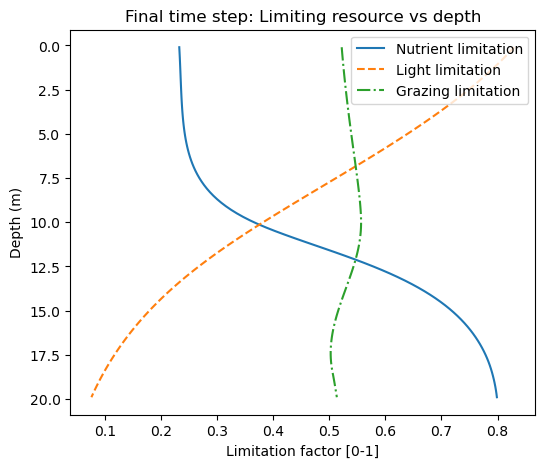

In [6]:
IO = light_damping(p, solution.y[0:p.ncells,-1])
fL = IO/(p.kL + IO)  # Use the last time step value of IO
fN = Nf / (p.kN + Nf)
fP = Pf / (p.kZ + Pf)

plt.figure(figsize=(6,5))
plt.plot(fN, p.grid, label="Nutrient limitation")
plt.plot(fL, p.grid, linestyle='--', label="Light limitation")
plt.plot(fP, p.grid, linestyle='-.', label="Grazing limitation")
plt.gca().invert_yaxis()
plt.legend()
plt.title("Final time step: Limiting resource vs depth")
plt.xlabel("Limitation factor [0-1]")
plt.ylabel("Depth (m)")
plt.show()


# Model with seasonality

In [ ]:
class Parameters:
    def __init__(self, ncells=100, z=20):
        self.w = 0.1  # Velocity in m/d (done)
        self.z = z # Depth in m
        # self.kappa = 0.3    # Mixing rate (m/day)

        # Define grid
        self.ncells = ncells  # Number of cells
        self.dz = self.z / self.ncells  # Cell size in m
        self.grid = np.arange(self.dz/2, self.z + self.dz/2, self.dz)  # Grid points at cell centers

        # parameters for phytoplankton growth
        self.kN = 0.3       # Nutrient half-saturation constant (umolN/m3) (done)
        self.kL = 20.0      # Light half-saturation constant (umol photons/m2/s) (done)
        self.gPmax = 2.0    # Maximum growth rate (1/day) (done)
        self.mP = 0.07      # Mortality rate (1/day) (done)

        # parameters for nutrients
        self.Ndeep = 10.0   # Deep nutrient concentration (umolN/m3)

        # parameters for zooplankton
        self.gZmax = 1.0    # Maximum grazing rate (1/day) (done)
        self.eresp = 0.3    # respiration rate (xx) (done)
        self.egestion = 0.3 # egestion rate (xx) (done)
        self.mZ = 0.2      # mortality rate (1/day) (done)
        self.kZ = 1         # Grazing half-saturation constant (umolN/m3) (done)

        # parameters for detritus
        self.r = 0.1        # remineralization rate (1/day) (done)

        # parameters for time step
        self.dt = 1  # time step in days
        self.t_end = 365  # total simulation time in days
        self.t = np.arange(0, self.t_end + self.dt, self.dt)  # time array

        # constant light
        self.IO = np.full(self.ncells, 1400) # light intensity (umol photons/m2/s) (done)
        self.kw = 0.15 # light attenuation by sea water [m-1] (done)
        self.kp = 0.05 #0.05 # light attenuation by plankton [m2/mmolN] (done)

        # oxygen processes
        self.yP = 9 # oxygen produced per unit of phytoplankton growth (mmolO2/mmolN) (done)
        self.yN = 6.625 # oxygen consumed per unit of zooplankton respiration (mmolO2/mmolN) (done)
        self.kO2_surf = 10 # oxygen mixing at surface (m/d) (done)
        self.kO2_bott = 1 # oxygen mixing at bottom (m/d) (done)
        self.O2_eq = 260 # oxygen concentration in equilibrium with atm at 15oC and 35 PSU (mmolO2/m3)
        self.O2crit = 100 # critical oxygen concentration for zooplankton respiration

        # diffusivity parameters:
        self.kappa_surface = 10  # Diffusivity at the surface (m²/d) (done)
        self.kappa_bottom = 5   # Diffusivity at the bottom (m²/d) (done)
        self.z_mix = 10  # Depth of the mixing layer (m) (done)
        # self.zeta_mix = 10
        self.phi_mix = 2 # wdith of the pycnocline (m) (done)
        self.phi_max_steep = 4 # steepness of the transition in diffusivity (done)
        self.t_max_spring = 75 # days (done)
        self.z_mix_winter = self.z # assume fully mixed in winter (done)

# Varying diffusivity with depth
def kappa(p, z, t):
    # z_mix = 5  # Mixing depth in m
    # zeta_mix = 10  # Thickness of the transition layer in m
    kappa = 0.5 * (1.0 - np.tanh((z - z_mix_season(p,t))/p.phi_mix)) * (p.kappa_surface - p.kappa_bottom) + p.kappa_bottom
    # kappa = kappa + 0.2  # Ensure kappa is larger than 0
    return kappa

def z_mix_season(p,t):
    seasonal_factor = 0.5 * (1 - np.sin(2*np.pi*(t - p.t_max_spring)/365))
    seasonal_factor = seasonal_factor**p.phi_max_steep # make the transition sharper
    seasonal_factor = seasonal_factor * (p.z_mix_winter - p.z_mix) + p.z_mix 
    return seasonal_factor

def seasonal_light(p,t):
    IO_max = p.IO
    IO_min = 0
    IO = (np.sin(2*np.pi*t/365) + 1.0)/2 * (IO_max - IO_min) + IO_min
    IO = IO * np.exp(-0.1*p.grid)  # Light attenuation with depth
    return IO

def light_damping(p, P, t):
    IO = seasonal_light(p,t)
    IO = IO * np.exp(-p.kw*p.grid - np.cumsum(P*p.dz*p.kp))
    return IO

def flux(p, kappa, phi, t):
    Ja = np.zeros(p.ncells + 1)  # Initialize advection flux array
    Jd = np.zeros(p.ncells + 1)  # Initialize diffusion flux array
    J = np.zeros(p.ncells + 1)   # Initialize total flux array

    # Advection flux at interior points
    Ja[0] = 0  # No flux at the surface
    Ja[1:p.ncells+1] = p.w * phi[0:p.ncells]
    Ja[-1] = 0  # No flux at the bottom

    # Diffusion flux at interior points
    K = kappa(p,p.grid,t)
    Jd[0] = 0  # No flux at the surface
    Jd[1:p.ncells] = -K[1:p.ncells] * (phi[1:p.ncells] - phi[0:p.ncells - 1]) / p.dz
    # Jd[-1] = 0  # No flux at the bottom

    # Total flux is sum of advection and diffusion fluxes
    J = Ja + Jd
    return J

def calc_uptake(p, N, P, O, t):
    IO = light_damping(p,P, t)
    gP = np.minimum(N/(p.kN + N), IO/(p.kL + IO)) 

    fO = 1/(1+np.exp(p.O2crit-O))               # oxygen limitation function, with a sharp transition around O=100 mmolO2/m3
    gZ = p.gZmax * P/(p.kZ + P) * fO           # Grazing rate from zooplankton
    return gP, gZ, IO

def derivatives(t, state, p):
    P = state[0:p.ncells]  # Phytoplankton concentration
    N = state[p.ncells:2*p.ncells]  # Nutrient concentration
    Z = state[2*p.ncells:3*p.ncells]  # Zooplankton concentration
    D = state[3*p.ncells:4*p.ncells]  # Detritus concentration
    O = state[4*p.ncells:] # Oxygen concentration

    JP = flux(p, kappa, P, t)  # Calculate flux based on phytoplankton concentration
    JN = flux(p, kappa, N, t)  # Calculate flux based on nutrient concentration
    JZ = flux(p, kappa, Z, t)  # Calculate flux based on zooplankton concentration
    JD = flux(p, kappa, D, t)  # Calculate flux based on detritus concentration
    JO = flux(p, kappa, O, t)  # Calculate flux based on oxygen concentration

    # No flux at surface for all components
    JP[0], JN[0], JZ[0], JD[0] = 0,0,0,0

    # Oxygen surface air–water exchange
    JO[0] = p.kO2_surf * (p.O2_eq - O[0])

    # Oxygen bottom sediment sink (O_sed = 0)
    JO[p.ncells] = -p.kO2_bott * (0.0 - O[-1])

    dPdt = np.zeros_like(P)
    dNdt = np.zeros_like(N)
    dZdt = np.zeros_like(Z)
    dDdt = np.zeros_like(D)
    dOdt = np.zeros_like(O)

    gP, gZ, _ = calc_uptake(p, N, P, O, t)

    dPdt = -(JP[1:p.ncells+1] - JP[0:p.ncells]) / p.dz + \
            gP*P - \
            gZ*Z - \
            p.mP*P

    dNdt = -(JN[1:p.ncells+1] - JN[0:p.ncells]) / p.dz + \
            -gP*P + \
            p.eresp*gZ*Z + \
            p.r*D

    dZdt = -(JZ[1:p.ncells+1] - JZ[0:p.ncells]) / p.dz + \
            (1-p.eresp-p.egestion)*gZ*Z - \
            p.mZ*Z
    
    dDdt = -(JD[1:p.ncells+1] - JD[0:p.ncells]) / p.dz + \
            p.mP*P + \
            p.mZ*Z + \
            p.egestion*gZ*Z - \
            p.r*D
    
    dOdt = -(JO[1:p.ncells+1] - JO[0:p.ncells]) / p.dz + \
            p.yP*gP*P - \
            p.yN*p.eresp*gZ*Z - \
            p.yN*p.r*D

    return np.concatenate([dPdt, dNdt, dZdt, dDdt, dOdt])

def run_AD_model():
    # Initialize parameters
    p = Parameters()
    
    # Initial condition Phyt: concentration is 1 everywhere except at the surface
    Phy0 = np.ones(p.ncells)
    # Phy0[0] = 1.0  # initial concentration at surface
    
    # Initial condition Nutrient: concentration is 1 everywhere except at the bottom
    Nut0 = np.ones(p.ncells)
    # Nut0[0] = 1.0  # initial concentration at surface

    # Initial condition Zooplankton: concentration is 1 everywhere
    Zoo0 = np.ones(p.ncells)
    # Zoo0[0] = 1.0  # initial concentration at surface

    # Initial condition Detritus: concentration is 1 everywhere
    D0 = np.ones(p.ncells)
    # D0[0] = 1.0  # initial concentration at surface

    # Initial condition Oxygen: concentration is 1 everywhere
    O0 = np.ones(p.ncells)
    # O0[0] = 1.0  # initial concentration at surface

    # Combine initial conditions
    initial_state = np.concatenate([Phy0, Nut0, Zoo0, D0, O0])

    # Time integration using scipy.integrate.odeint
    scale = 2
    t_end = scale*365
    t_span = (0, t_end)
    t = np.linspace(t_span[0], t_span[1], scale*2000) # time steps = 2000
    solution = solve_ivp(derivatives, [0, t_end], initial_state, args=(p,), t_eval=t, method='LSODA')

    return solution

In [8]:
p = Parameters()
solution = run_AD_model()

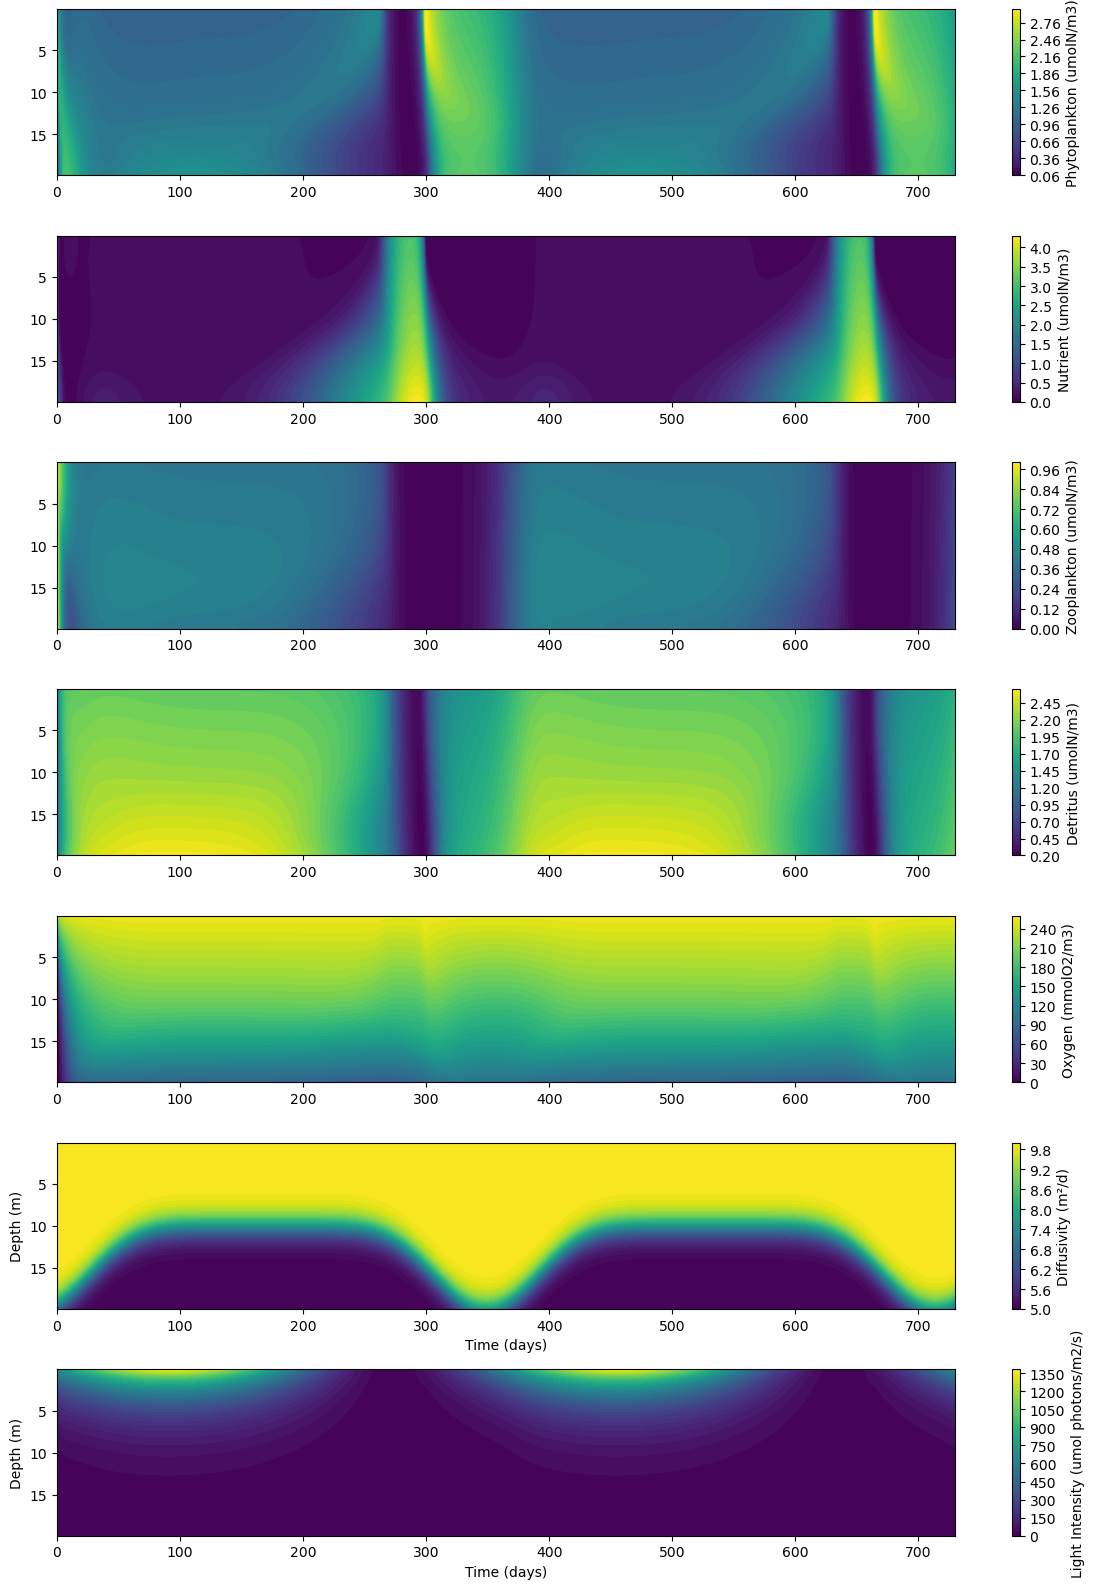

In [9]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(12, 16))
gs = GridSpec(7, 1, height_ratios=[1,1,1,1,1,1,1])  # 6 rows, 2 columns

# ----- Row 1: full width -----
ax1 = fig.add_subplot(gs[0, :])
c1 = ax1.contourf(solution.t, p.grid, solution.y[0:p.ncells, :], levels=50, cmap='viridis')
fig.colorbar(c1, ax=ax1, label='Phytoplankton (umolN/m3)')
ax1.invert_yaxis()
# ax1.set_title("Phytoplankton")

# ----- Row 2: full width -----
ax2 = fig.add_subplot(gs[1, :])
c2 = ax2.contourf(solution.t, p.grid, solution.y[p.ncells:2*p.ncells, :], levels=50, cmap='viridis')
fig.colorbar(c2, ax=ax2, label='Nutrient (umolN/m3)')
ax2.invert_yaxis()
# ax2.set_title("Nutrients")

# ----- Row 3: full width -----
ax3 = fig.add_subplot(gs[2, :])
c3 = ax3.contourf(solution.t, p.grid, solution.y[2*p.ncells:3*p.ncells, :], levels=50, cmap='viridis')
fig.colorbar(c3, ax=ax3, label='Zooplankton (umolN/m3)')
ax3.invert_yaxis()
# ax3.set_title("Zooplankton")

# ----- Row 4: full width -----
ax4 = fig.add_subplot(gs[3, :])
c4 = ax4.contourf(solution.t, p.grid, solution.y[3*p.ncells:4*p.ncells, :], levels=50, cmap='viridis')
fig.colorbar(c4, ax=ax4, label='Detritus (umolN/m3)')
ax4.invert_yaxis()
# ax4.set_title("Detritus")

# ----- Row 5: full width -----
ax5 = fig.add_subplot(gs[4, :])
c5 = ax5.contourf(solution.t, p.grid, solution.y[4*p.ncells:, :], levels=50, cmap='viridis')
fig.colorbar(c5, ax=ax5, label='Oxygen (mmolO2/m3)')
ax5.invert_yaxis()
# ax5.set_title("Oxygen")

# ----- Row 5: two plots side by side -----
# Left plot: kappa
scale = 2
t_end = scale*365
t_span = (0, t_end)
t = np.linspace(t_span[0], t_span[1], scale*2000)
kappa_profile = np.array([kappa(p, p.grid, t_i) for t_i in t])
ax6 = fig.add_subplot(gs[5, :])
# ax6.plot(kappa(p, p.grid), p.grid)
# ax6.invert_yaxis()
# ax6.set_xlabel("Turbulent Diffusivity (m²/d)")
plt.contourf(t, p.grid, kappa_profile.T, levels=50, cmap='viridis')
plt.colorbar(label='Diffusivity (m²/d)')
plt.xlabel('Time (days)')
plt.ylabel('Depth (m)')
# plt.title('Diffusivity Profile Over Time and Depth')
plt.gca().invert_yaxis()  # Invert y-axis to have depth increasing downwards
# plt.show()

# Right plot: light
ax7 = fig.add_subplot(gs[6, :])
# IO = light_damping(p, solution.y[0:p.ncells,-1])
seasonal_damping_IO = np.array([light_damping(p, solution.y[0:p.ncells, i], t_i) for i, t_i in enumerate(t)])
# ax7.plot(seasonal_damping_IO.T, p.grid)
# ax7.invert_yaxis()
# ax7.set_xlabel("Light Intensity (umol photons/m²/s)")
plt.contourf(t, p.grid, seasonal_damping_IO.T, levels=50, cmap='viridis')
plt.colorbar(label='Light Intensity (umol photons/m2/s)')
plt.xlabel('Time (days)')
plt.ylabel('Depth (m)')
# plt.title('Seasonal light intensity')
plt.gca().invert_yaxis()  # Invert y-axis to have depth increasing downwards
# plt.show()

plt.tight_layout()
plt.show()